In [30]:
# =========================================
# 1. IMPORT LIBRARIES + PROFESSIONAL THEME
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns
pd.set_option('display.max_columns', None)

# =========================================
# 🎨 PROFESSIONAL LIGHT THEME (FOR SEMINAR)
# =========================================

# Main colors
PRIMARY_COLOR = "#2C3E50"     # Dark Blue (professional)
ACCENT_COLOR = "#E74C3C"      # Red (highlight)
SECONDARY_COLOR = "#7F8C8D"   # Grey

# Apply clean style
sns.set_theme(style="whitegrid")

# Custom palette
sns.set_palette([PRIMARY_COLOR, ACCENT_COLOR, SECONDARY_COLOR])

# Clean background settings
plt.rcParams['figure.facecolor'] = "white"
plt.rcParams['axes.facecolor'] = "white"
plt.rcParams['axes.edgecolor'] = "black"
plt.rcParams['axes.labelcolor'] = "black"
plt.rcParams['xtick.color'] = "black"
plt.rcParams['ytick.color'] = "black"
plt.rcParams['text.color'] = "black"

In [31]:
# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("/content/netflix_titles.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [32]:
# =========================================
# DATASET SUMMARY
# =========================================
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Insight:")
print("Dataset contains Movies and TV Shows with attributes like genre, country, duration, and release year.")

Number of Rows: 8807
Number of Columns: 12

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Target Insight:
Dataset contains Movies and TV Shows with attributes like genre, country, duration, and release year.


In [33]:
# =========================================
# 3. DATA UNDERSTANDING
# =========================================
df.info()

print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
des

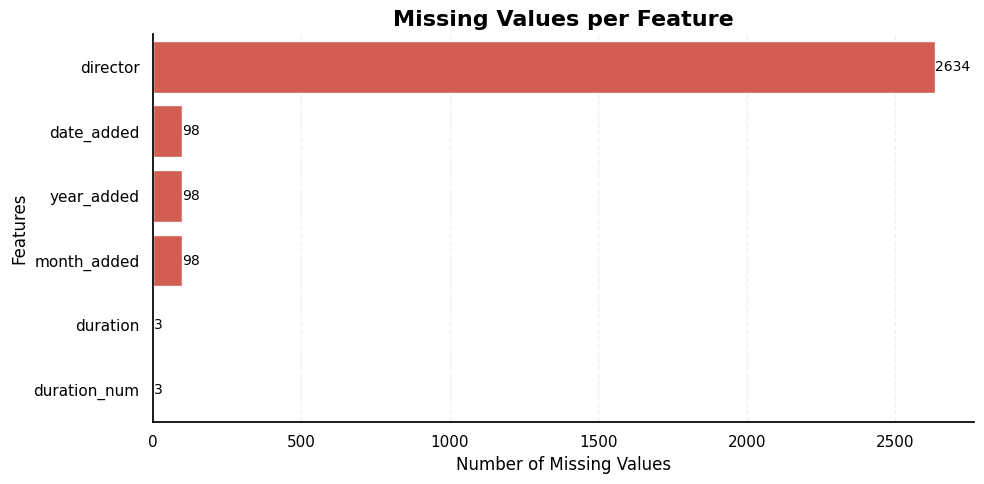

In [58]:
# =========================================
# MISSING VALUES VISUALIZATION (PRO VERSION)
# =========================================

# Calculate missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))

# Bar plot instead of messy heatmap
sns.barplot(x=missing.values, y=missing.index, color="#E74C3C")

# Add value labels
for i, v in enumerate(missing.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=10)

# Titles and labels
plt.title("Missing Values per Feature", fontsize=16, weight='bold')
plt.xlabel("Number of Missing Values")
plt.ylabel("Features")

# Clean look
sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# =========================================
# 4. DATA CLEANING
# =========================================

# Convert date
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year & month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Fill missing values
df['country'].fillna("Unknown", inplace=True)
df['rating'].fillna("Not Rated", inplace=True)

# Split genres
df['listed_in'] = df['listed_in'].str.split(',')

print("Data Cleaning Completed ✔")

Data Cleaning Completed ✔


/tmp/ipykernel_7395/769393644.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna("Unknown", inplace=True)
/tmp/ipykernel_7395/769393644.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [36]:
# =========================================
# 5. FEATURE ENGINEERING
# =========================================

# Extract numeric duration
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

# Content age
df['content_age'] = 2024 - df['release_year']

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7395/2593942615.py:6: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


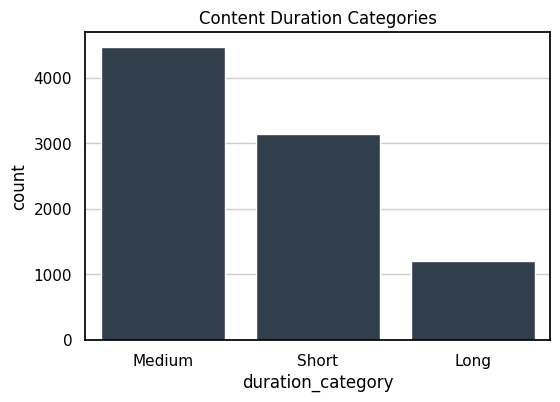

In [37]:
# =========================================
# DURATION CATEGORY
# =========================================
def duration_category(x):
    if x < 60:
        return "Short"
    elif x < 120:
        return "Medium"
    else:
        return "Long"

df['duration_category'] = df['duration_num'].apply(duration_category)

plt.figure(figsize=(6,4))
sns.countplot(x='duration_category', data=df)

plt.title("Content Duration Categories")
plt.show()

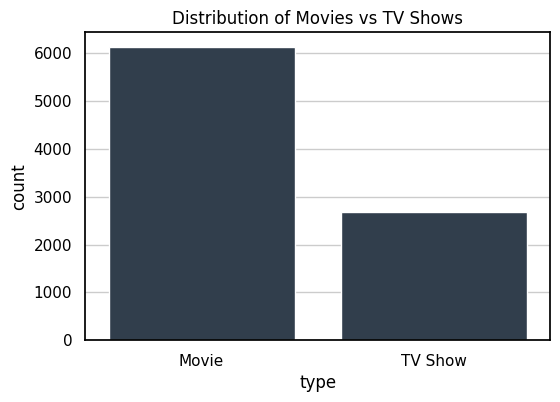

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.show()

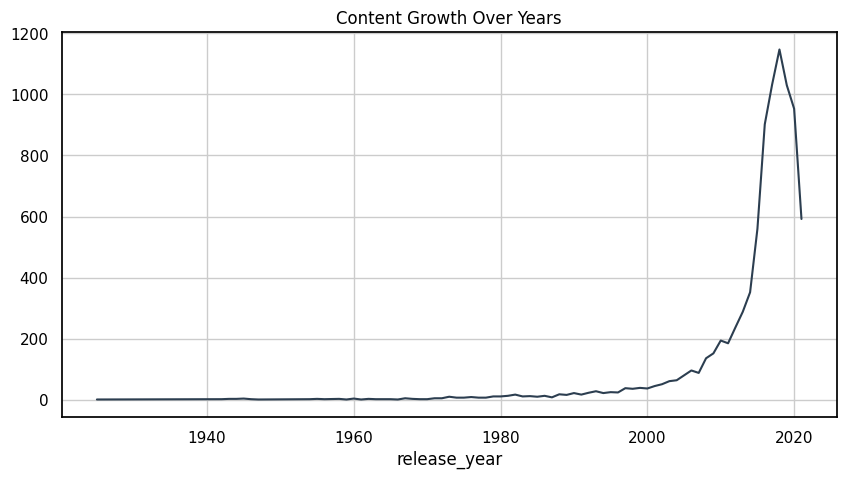

In [39]:
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.show()

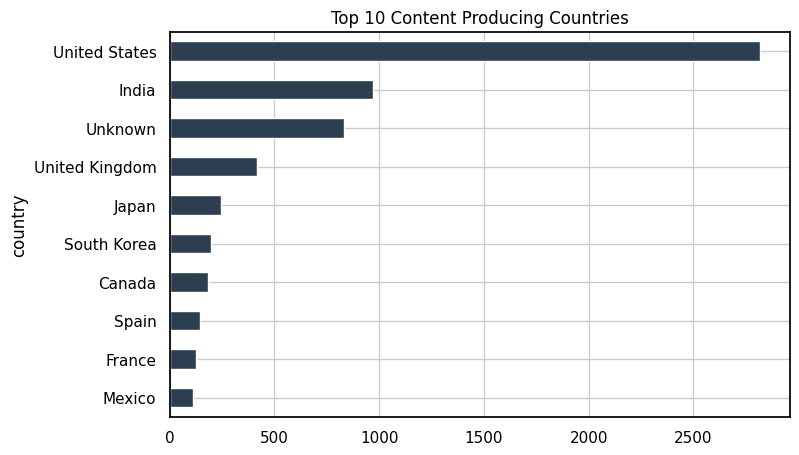

In [40]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_countries.plot(kind='barh')

plt.title("Top 10 Content Producing Countries")
plt.gca().invert_yaxis()
plt.show()

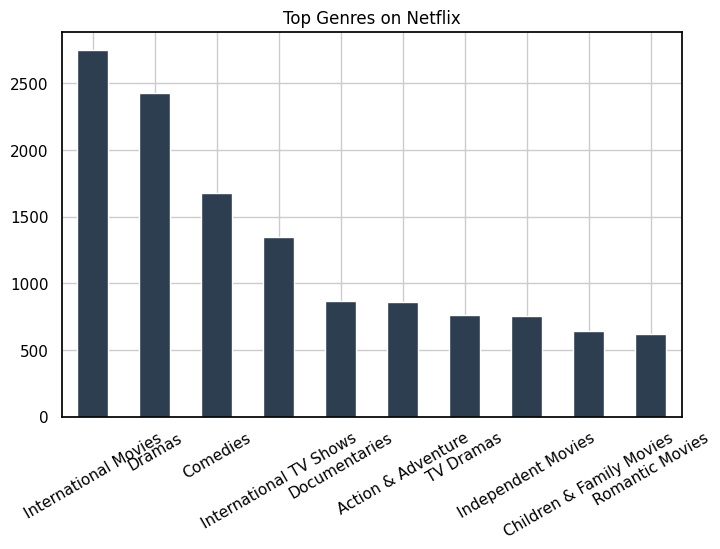

In [41]:
from itertools import chain

genres = list(chain.from_iterable(df['listed_in'].dropna()))
genre_series = pd.Series(genres).str.strip()

top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(8,5))
top_genres.plot(kind='bar')

plt.title("Top Genres on Netflix")
plt.xticks(rotation=30)
plt.show()

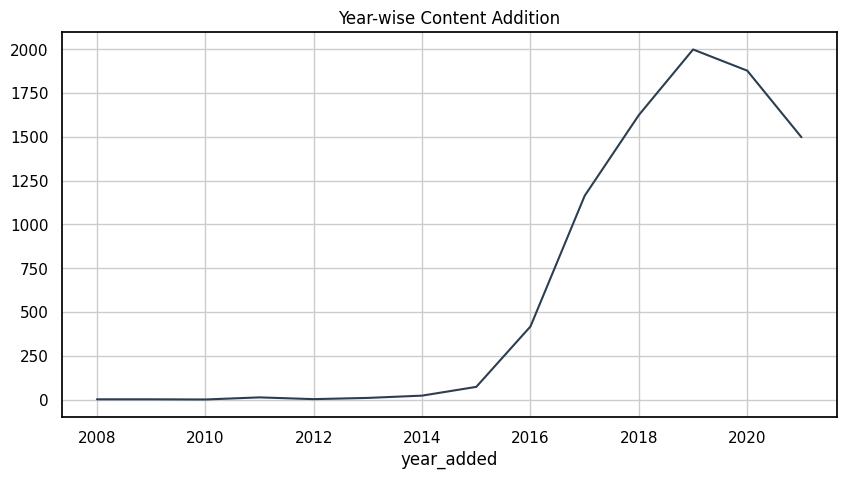

In [42]:
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot()
plt.title("Year-wise Content Addition")
plt.show()

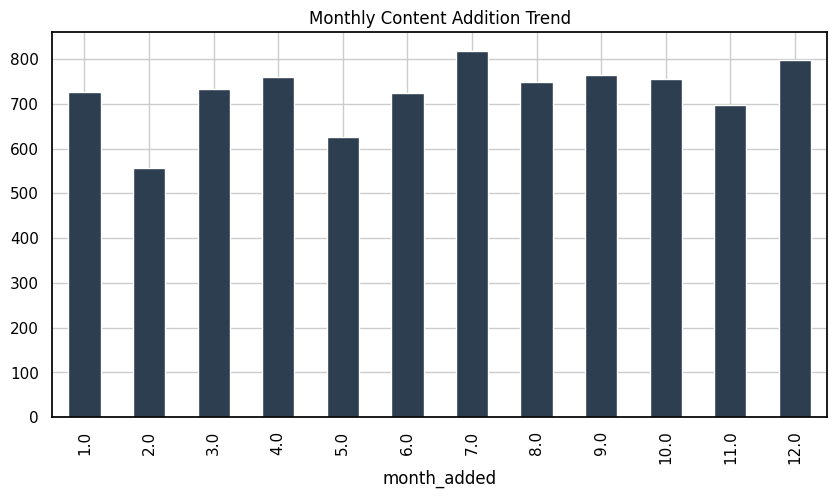

In [43]:
plt.figure(figsize=(10,5))
df['month_added'].value_counts().sort_index().plot(kind='bar')

plt.title("Monthly Content Addition Trend")
plt.show()


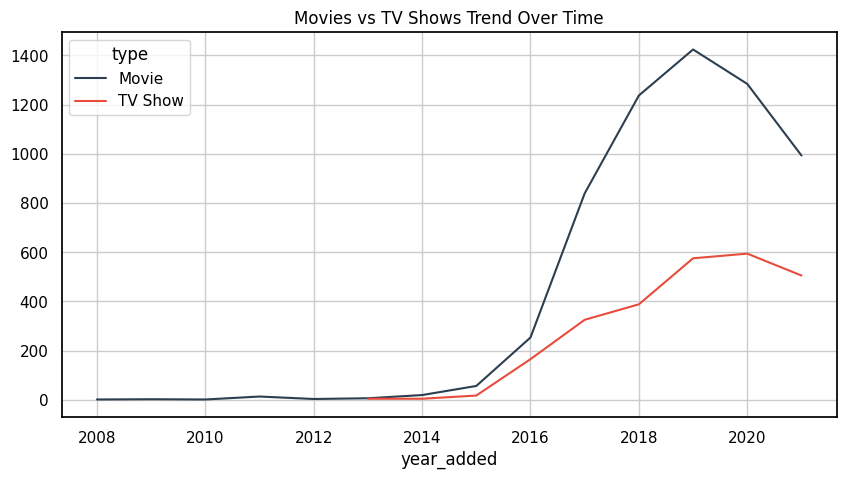

In [44]:
content_trend = df.groupby(['year_added','type']).size().unstack()

content_trend.plot(figsize=(10,5))
plt.title("Movies vs TV Shows Trend Over Time")
plt.show()

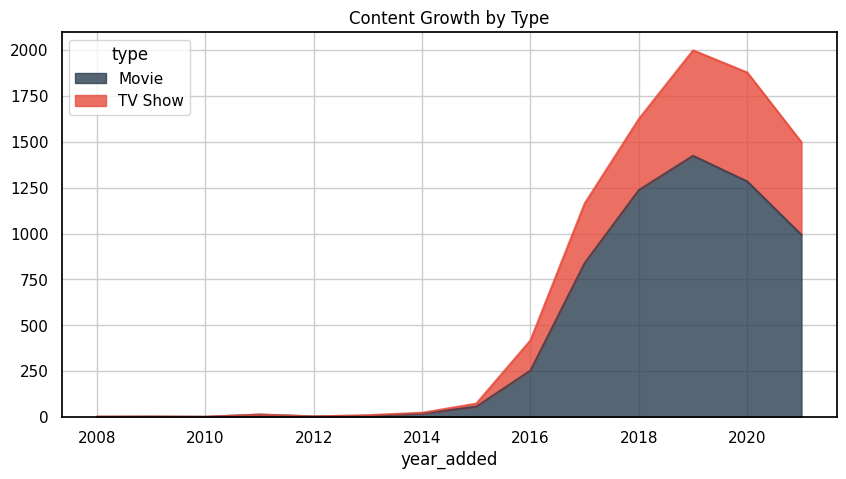

In [45]:
content_year = df.groupby(['year_added','type']).size().unstack()

content_year.plot(kind='area', stacked=True, figsize=(10,5), alpha=0.8)

plt.title("Content Growth by Type")
plt.show()

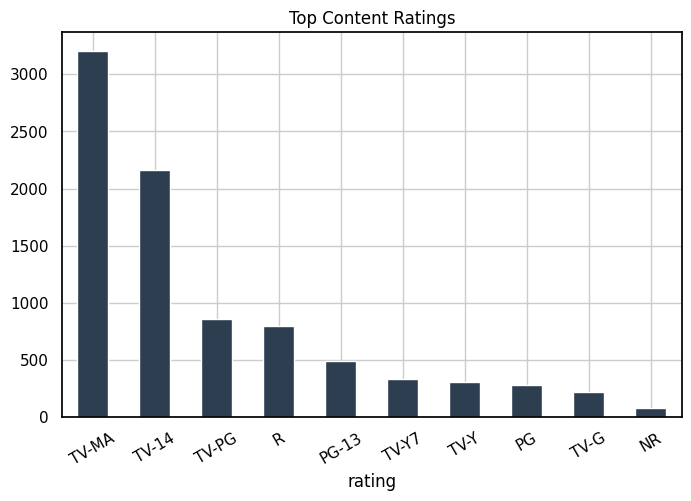

In [46]:
plt.figure(figsize=(8,5))
df['rating'].value_counts().head(10).plot(kind='bar')

plt.title("Top Content Ratings")
plt.xticks(rotation=30)
plt.show()

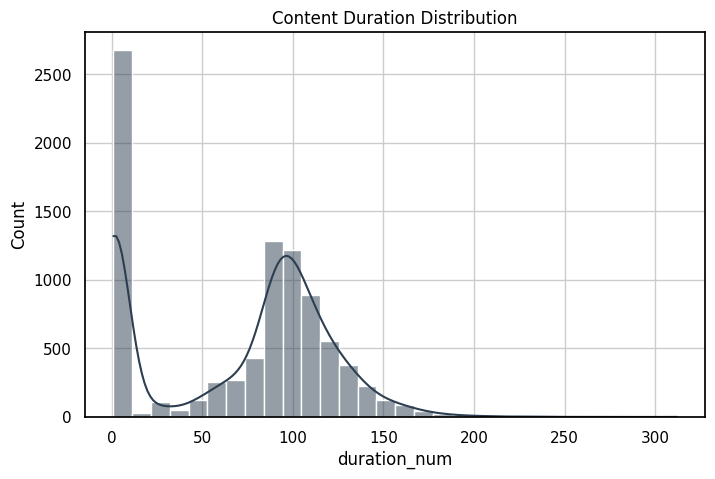

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(df['duration_num'], bins=30, kde=True)

plt.title("Content Duration Distribution")
plt.show()

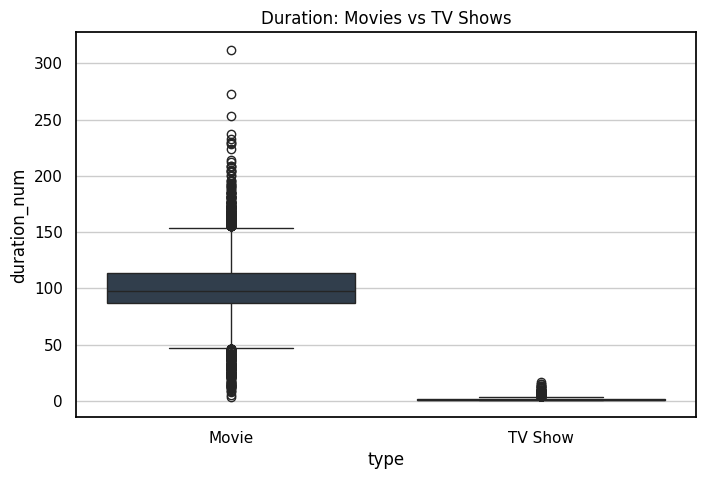

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='duration_num', data=df)

plt.title("Duration: Movies vs TV Shows")
plt.show()

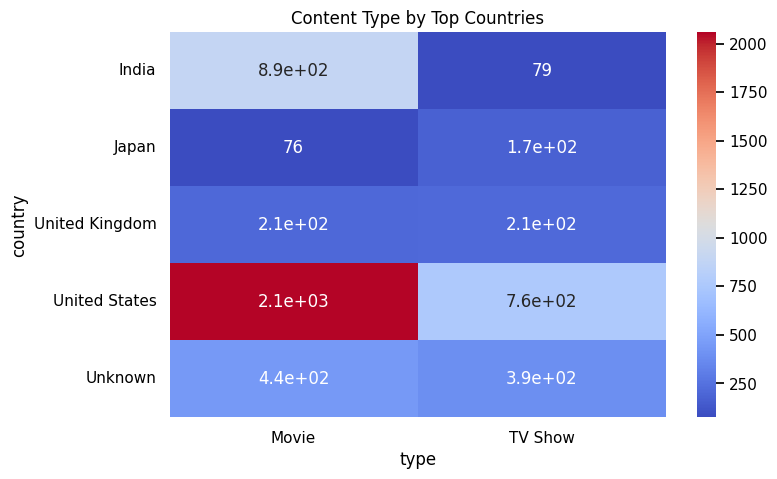

In [49]:
top_countries = df['country'].value_counts().head(5).index
filtered = df[df['country'].isin(top_countries)]

pivot = pd.crosstab(filtered['country'], filtered['type'])

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='coolwarm')

plt.title("Content Type by Top Countries")
plt.show()

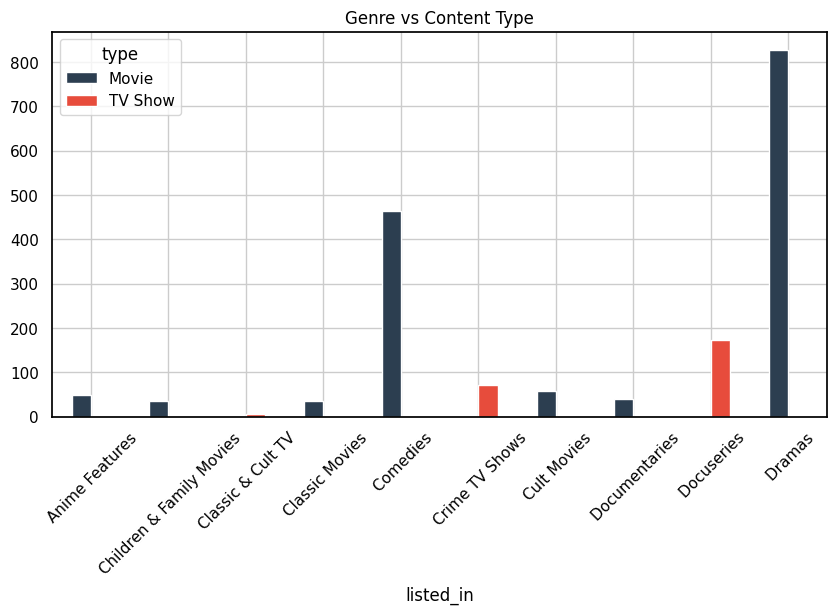

In [50]:
df_genre = df.explode('listed_in')

pivot_genre = pd.crosstab(df_genre['listed_in'], df_genre['type'])

pivot_genre.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Genre vs Content Type")
plt.xticks(rotation=45)
plt.show()

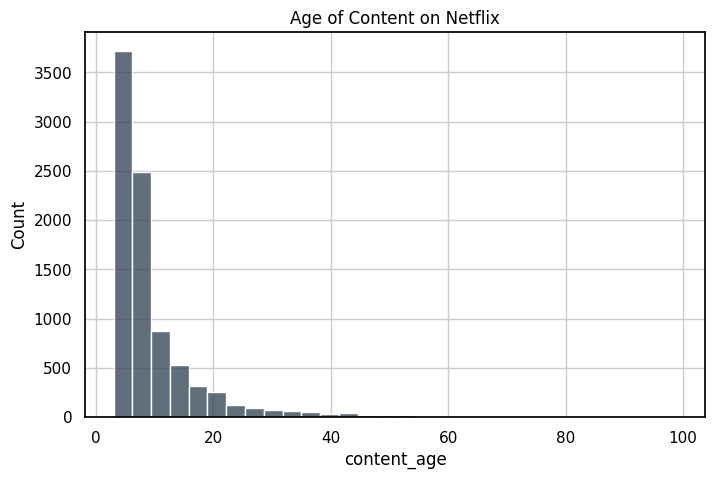

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df['content_age'], bins=30)

plt.title("Age of Content on Netflix")
plt.show()

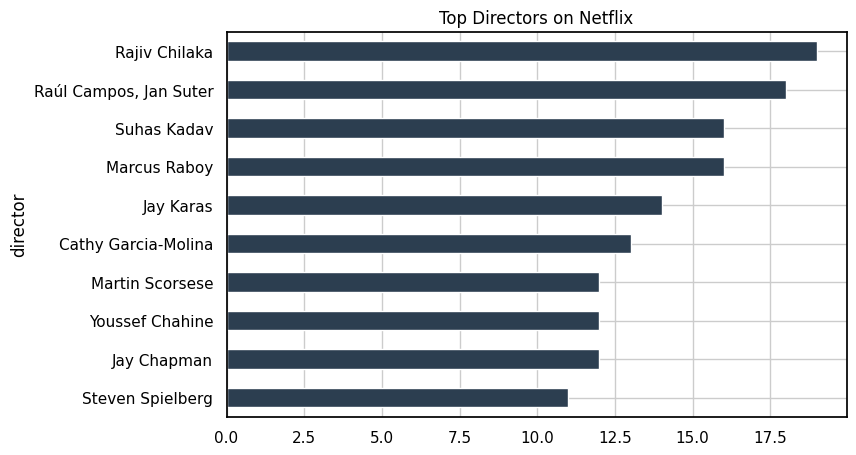

In [52]:
top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_directors.plot(kind='barh')

plt.title("Top Directors on Netflix")
plt.gca().invert_yaxis()
plt.show()

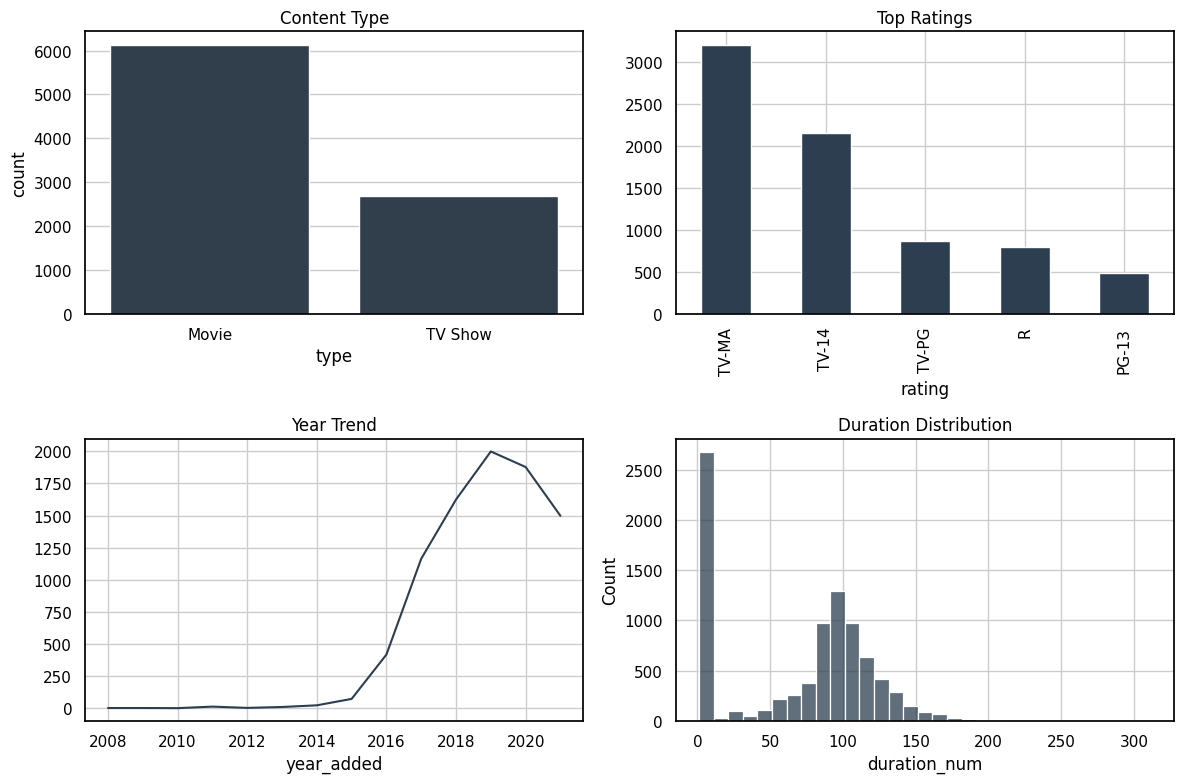

In [53]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.countplot(x='type', data=df, ax=axes[0,0])
axes[0,0].set_title("Content Type")

df['rating'].value_counts().head(5).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Top Ratings")

df['year_added'].value_counts().sort_index().plot(ax=axes[1,0])
axes[1,0].set_title("Year Trend")

sns.histplot(df['duration_num'], ax=axes[1,1])
axes[1,1].set_title("Duration Distribution")

plt.tight_layout()
plt.show()

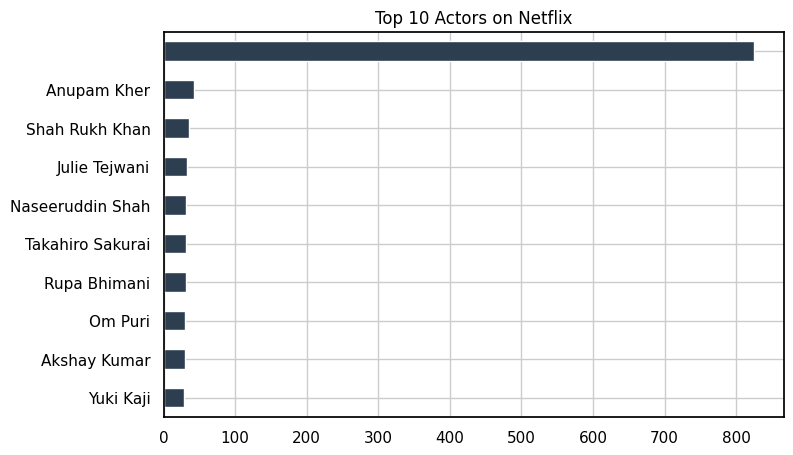

In [54]:
# =========================================
# TOP ACTORS
# =========================================
from itertools import chain

df['cast'] = df['cast'].fillna('')
actors = list(chain.from_iterable(df['cast'].str.split(',')))
actors_series = pd.Series(actors).str.strip()

top_actors = actors_series.value_counts().head(10)

plt.figure(figsize=(8,5))
top_actors.plot(kind='barh')

plt.title("Top 10 Actors on Netflix")
plt.gca().invert_yaxis()
plt.show()

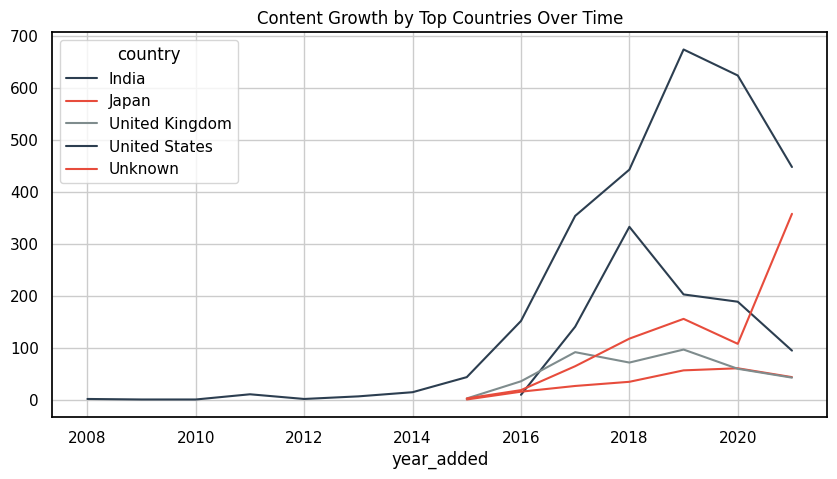

In [55]:
# =========================================
# COUNTRY VS YEAR TREND
# =========================================
top_countries = df['country'].value_counts().head(5).index
filtered = df[df['country'].isin(top_countries)]

trend = filtered.groupby(['year_added','country']).size().unstack()

trend.plot(figsize=(10,5))

plt.title("Content Growth by Top Countries Over Time")
plt.show()

In [56]:
print("\n🔍 KEY INSIGHTS:")
print("• Netflix has more Movies than TV Shows.")
print("• Content increased rapidly after 2015.")
print("• USA dominates content production.")
print("• Drama and International genres are most common.")
print("• Netflix is expanding globally.")


🔍 KEY INSIGHTS:
• Netflix has more Movies than TV Shows.
• Content increased rapidly after 2015.
• USA dominates content production.
• Drama and International genres are most common.
• Netflix is expanding globally.


In [57]:
# =========================================
# BUSINESS RECOMMENDATIONS
# =========================================
print("\n📊 BUSINESS RECOMMENDATIONS:")
print("• Increase production of high-demand genres like Drama and International content.")
print("• Expand content in emerging countries to attract global audiences.")
print("• Focus on medium-length content which is most common.")
print("• Invest in popular actors and directors to increase engagement.")
print("• Maintain a balance between Movies and TV Shows.")


📊 BUSINESS RECOMMENDATIONS:
• Increase production of high-demand genres like Drama and International content.
• Expand content in emerging countries to attract global audiences.
• Focus on medium-length content which is most common.
• Invest in popular actors and directors to increase engagement.
• Maintain a balance between Movies and TV Shows.
